**PNV3421**

In [20]:
# ===============================
# 1. IMPORTAÇÃO E CARREGAMENTO
# ===============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, acf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

# Carregar dataset
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/dataset.txt",
                 parse_dates=["date"])
df = df.set_index("date")
df.head()

,value
date,
1991-07-01,3.526591
1991-08-01,3.180891
1991-09-01,3.252221
1991-10-01,3.611003
1991-11-01,3.565869


In [21]:
# ===============================
# 2. TESTE DE ESTACIONARIDADE
# ===============================
result = adfuller(df.value.dropna())
print(f"ADF: {result[0]}")
print(f"p-value: {result[1]}")

plt.rcParams.update({'figure.figsize':(10,7), 'figure.dpi':120})

ADF: 3.14518568930673
p-value: 1.0


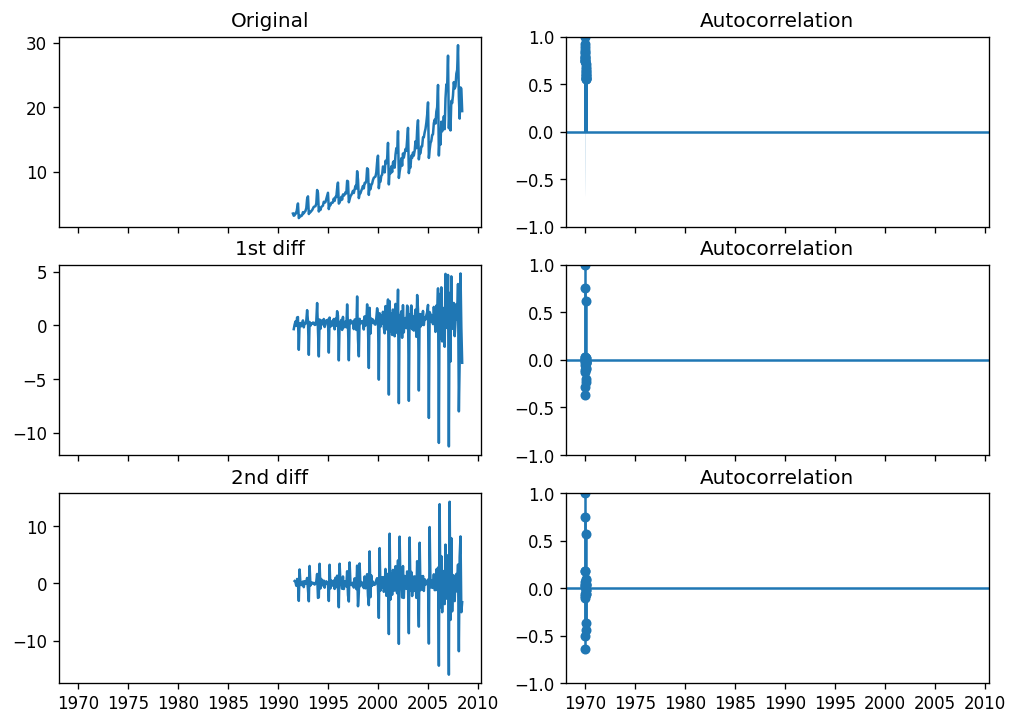

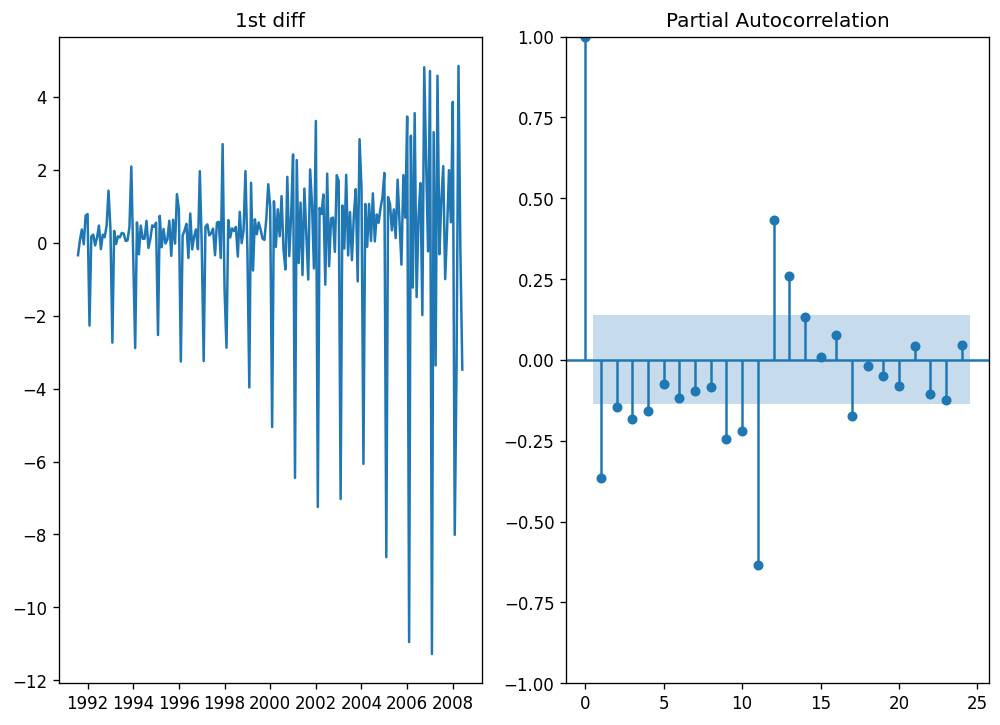

In [22]:
# ===============================
# 3. ACF / PACF E DIFERENCIAÇÃO
# ===============================
fig, axes = plt.subplots(3, 2, sharex=True)

axes[0,0].plot(df.value); axes[0,0].set_title("Original")
plot_acf(df.value, ax=axes[0,1])

axes[1,0].plot(df.value.diff()); axes[1,0].set_title("1st diff")
plot_acf(df.value.diff().dropna(), ax=axes[1,1])

axes[2,0].plot(df.value.diff().diff()); axes[2,0].set_title("2nd diff")
plot_acf(df.value.diff().diff().dropna(), ax=axes[2,1])

plt.show()

# PACF
fig, ax = plt.subplots(1,2)
ax[0].plot(df.value.diff()); ax[0].set_title("1st diff")
plot_pacf(df.value.diff().dropna(), ax=ax[1])
plt.show()

In [23]:
# ===============================
# 4. AJUSTE DE MODELOS ARIMA
# ===============================

print("\n==== ARIMA(1,1,2) ====\n")
model = ARIMA(df.value, order=(1,1,2))
model_fit = model.fit()
print(model_fit.summary())

print("\n==== ARIMA(1,1,1) ====\n")
model = ARIMA(df.value, order=(1,1,1))
model_fit = model.fit()
print(model_fit.summary())


==== ARIMA(1,1,2) ====

                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  204
Model:                 ARIMA(1, 1, 2)   Log Likelihood                -424.570
Date:                Thu, 13 Nov 2025   AIC                            857.140
Time:                        01:44:03   BIC                            870.393
Sample:                    07-01-1991   HQIC                           862.502
                         - 06-01-2008                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4178      0.356      1.174      0.240      -0.280       1.115
ma.L1         -0.9546      0.377     -2.531      0.011      -1.694      -0.215
ma.L2          0.0969      

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_date

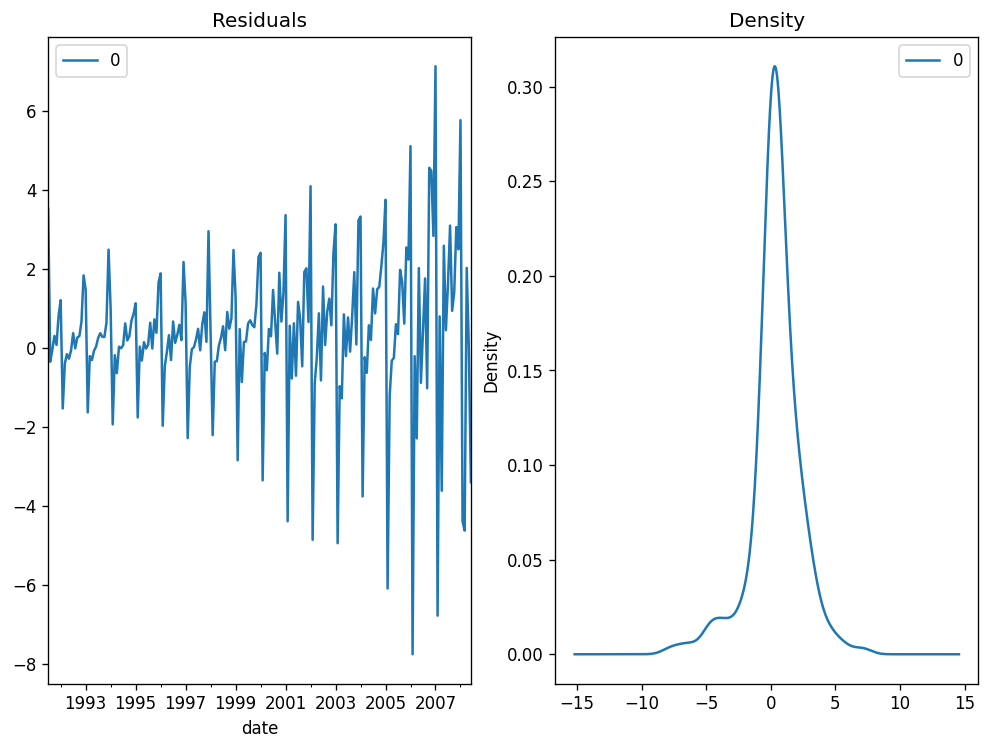

In [24]:
# ===============================
# 5. RESÍDUOS
# ===============================
residuals = pd.DataFrame(model_fit.resid)
fig, ax = plt.subplots(1,2)
residuals.plot(title="Residuals", ax=ax[0])
residuals.plot(kind='kde', title='Density', ax=ax[1])
plt.show()

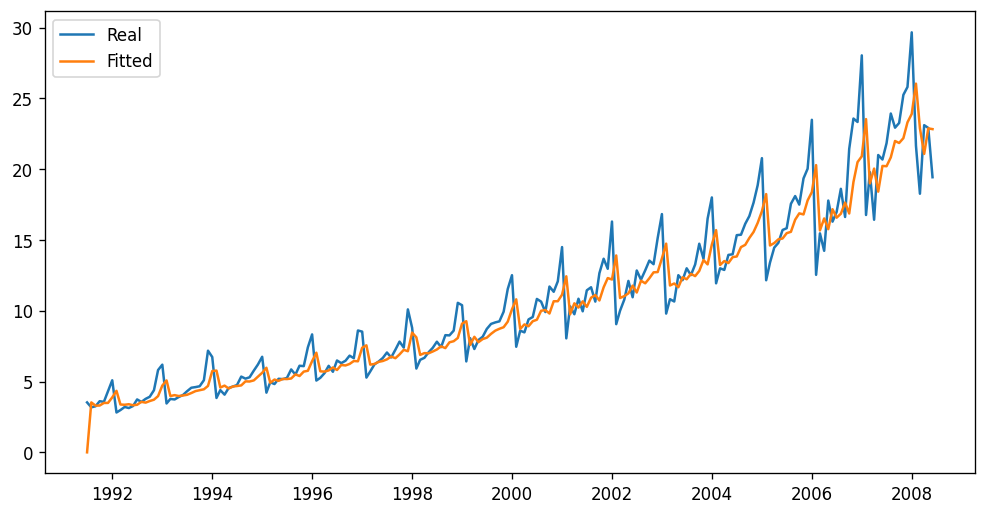

In [25]:
# ===============================
# 6. AJUSTE DENTRO DA AMOSTRA
# ===============================
pred = model_fit.get_prediction()
pred_ci = pred.conf_int()

plt.figure(figsize=(10,5))
plt.plot(df.index, df.value, label="Real")
plt.plot(pred.predicted_mean.index, pred.predicted_mean, label="Fitted")
plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


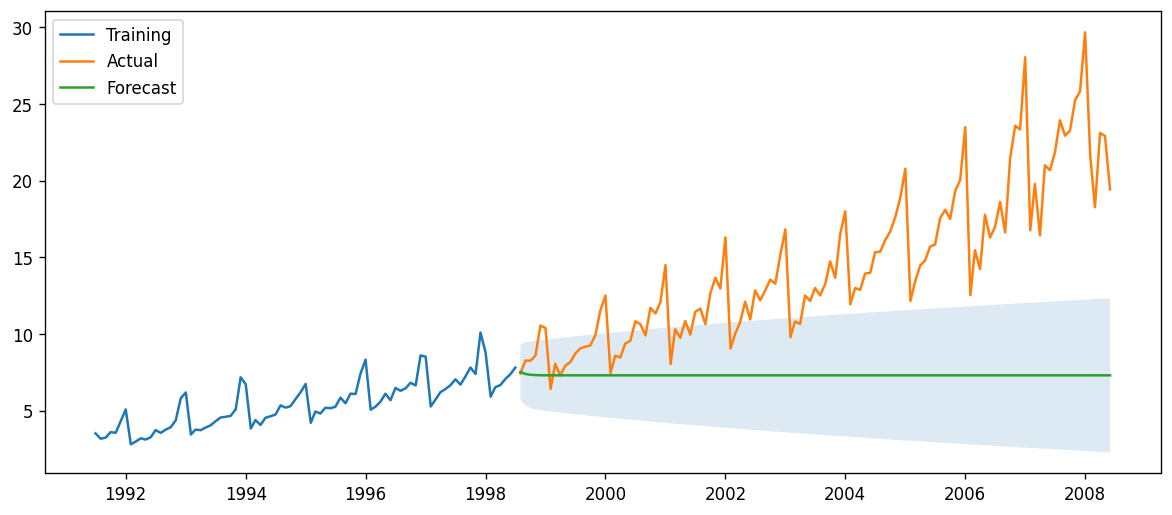

In [26]:
# ===============================
# 7. TREINO / TESTE
# ===============================
train = df.value[:85]
test = df.value[85:]

# ARIMA 1,1,1 para previsão no TESTE
model = ARIMA(train, order=(1,1,1))
fitted = model.fit()

pred = fitted.get_forecast(steps=len(test))
fc = pred.predicted_mean
conf = pred.conf_int()

fc_series = pd.Series(fc, index=test.index)
lower = pd.Series(conf.iloc[:,0], index=test.index)
upper = pd.Series(conf.iloc[:,1], index=test.index)

plt.figure(figsize=(12,5))
plt.plot(train, label="Training")
plt.plot(test, label="Actual")
plt.plot(fc_series, label="Forecast")
plt.fill_between(test.index, lower, upper, alpha=.15)
plt.legend()
plt.show()


==== ARIMA(3,2,1) ====



/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                   85
Model:                 ARIMA(3, 2, 1)   Log Likelihood                -116.886
Date:                Thu, 13 Nov 2025   AIC                            243.771
Time:                        01:44:47   BIC                            255.865
Sample:                    07-01-1991   HQIC                           248.630
                         - 07-01-1998                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2201      0.194     -1.136      0.256      -0.600       0.160
ar.L2         -0.3432      0.141     -2.437      0.015      -0.619      -0.067
ar.L3         -0.0932      0.252     -0.369      0.7

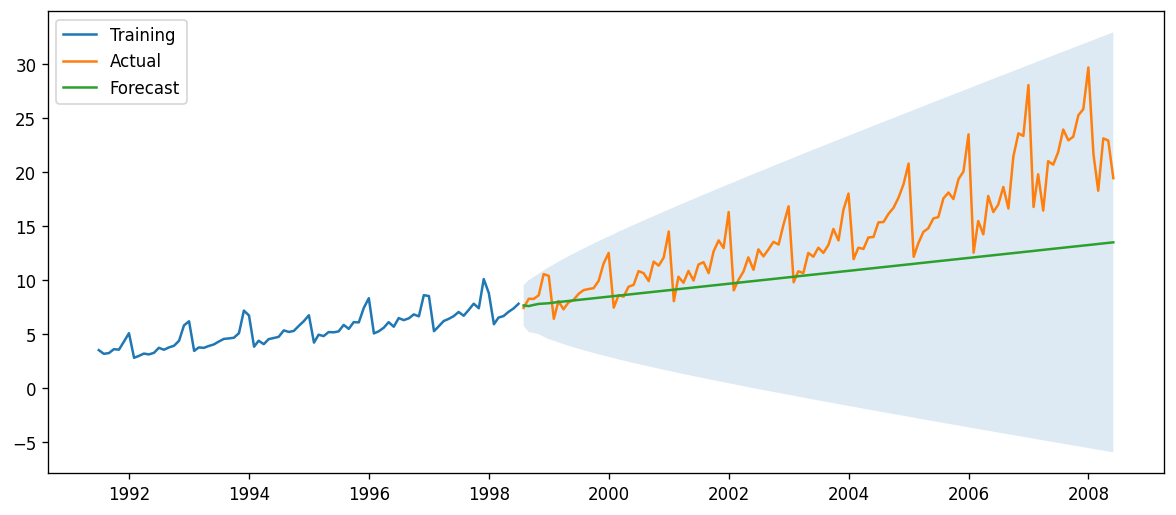

In [27]:
# ===============================
# 8. ARIMA 3,2,1 TREINADO
# ===============================
print("\n==== ARIMA(3,2,1) ====\n")
model = ARIMA(train, order=(3,2,1))
fitted = model.fit()
print(fitted.summary())

pred = fitted.get_forecast(steps=len(test))
fc = pred.predicted_mean
conf = pred.conf_int()

fc_series = pd.Series(fc, index=test.index)
lower = pd.Series(conf.iloc[:,0], index=test.index)
upper = pd.Series(conf.iloc[:,1], index=test.index)

plt.figure(figsize=(12,5))
plt.plot(train, label="Training")
plt.plot(test, label="Actual")
plt.plot(fc_series, label="Forecast")
plt.fill_between(test.index, lower, upper, alpha=.15)
plt.legend()
plt.show()

In [28]:
# ===============================
# 9. MÉTRICAS (FUNÇÃO CORRIGIDA)
# ===============================
def forecast_accuracy(forecast, actual):
    forecast = np.asarray(forecast)
    actual = np.asarray(actual)

    mape  = np.mean(np.abs(forecast - actual) / np.abs(actual))
    me    = np.mean(forecast - actual)
    mae   = np.mean(np.abs(forecast - actual))
    mpe   = np.mean((forecast - actual) / actual)
    rmse  = np.sqrt(np.mean((forecast - actual)**2))
    corr  = np.corrcoef(forecast, actual)[0,1]

    mins  = np.minimum(forecast, actual)
    maxs  = np.maximum(forecast, actual)
    minmax = 1 - np.mean(mins/maxs)

    erro = forecast - actual
    acf1 = acf(erro, fft=False)[1]

    return {'mape':mape,'me':me,'mae':mae,'mpe':mpe,
            'rmse':rmse,'corr':corr,'minmax':minmax,'acf1':acf1}

print("\nMÉTRICAS:")
print(forecast_accuracy(fc_series.values, test.values))


MÉTRICAS:
{'mape': np.float64(0.23263538322372354), 'me': np.float64(-3.8801439780860525), 'mae': np.float64(3.9812446547048452), 'mpe': np.float64(-0.21926641631598262), 'rmse': np.float64(5.306738385632411), 'corr': np.float64(0.8736886564850299), 'minmax': np.float64(0.2318357622317868), 'acf1': np.float64(0.6960181552567395)}


In [29]:
# ===============================
# 10. AUTO-ARIMA (VERSÃO CORRETA)
# ===============================
!pip install statsforecast datasetsforecast

from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA

# Formato do StatsForecast
df2 = pd.DataFrame({
    "unique_id": "serie1",
    "ds": df.index,
    "y": df.value
})

# Série é mensal → freq='MS'
sf = StatsForecast(
    models=[AutoARIMA(season_length=1)],
    freq='MS'
)

resultado = sf.forecast(df=df2, h=12)
print(resultado.head())


  unique_id         ds  AutoARIMA
0    serie1 2008-07-01  21.569238
1    serie1 2008-08-01  22.306966
2    serie1 2008-09-01  22.605005
3    serie1 2008-10-01  22.764929
4    serie1 2008-11-01  22.881470
